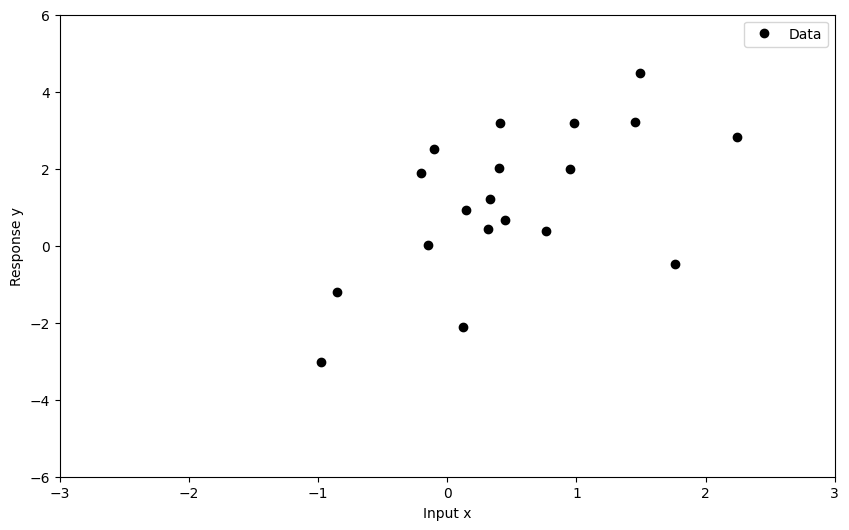


Configuration 1: Flat prior, baseline β
Alpha: 0.1, Beta: 0.75
MLE: [0.4804374 1.6728646]
MAP: [0.48447847 1.660096  ]
Posterior Mean: [0.4844786 1.6600962]


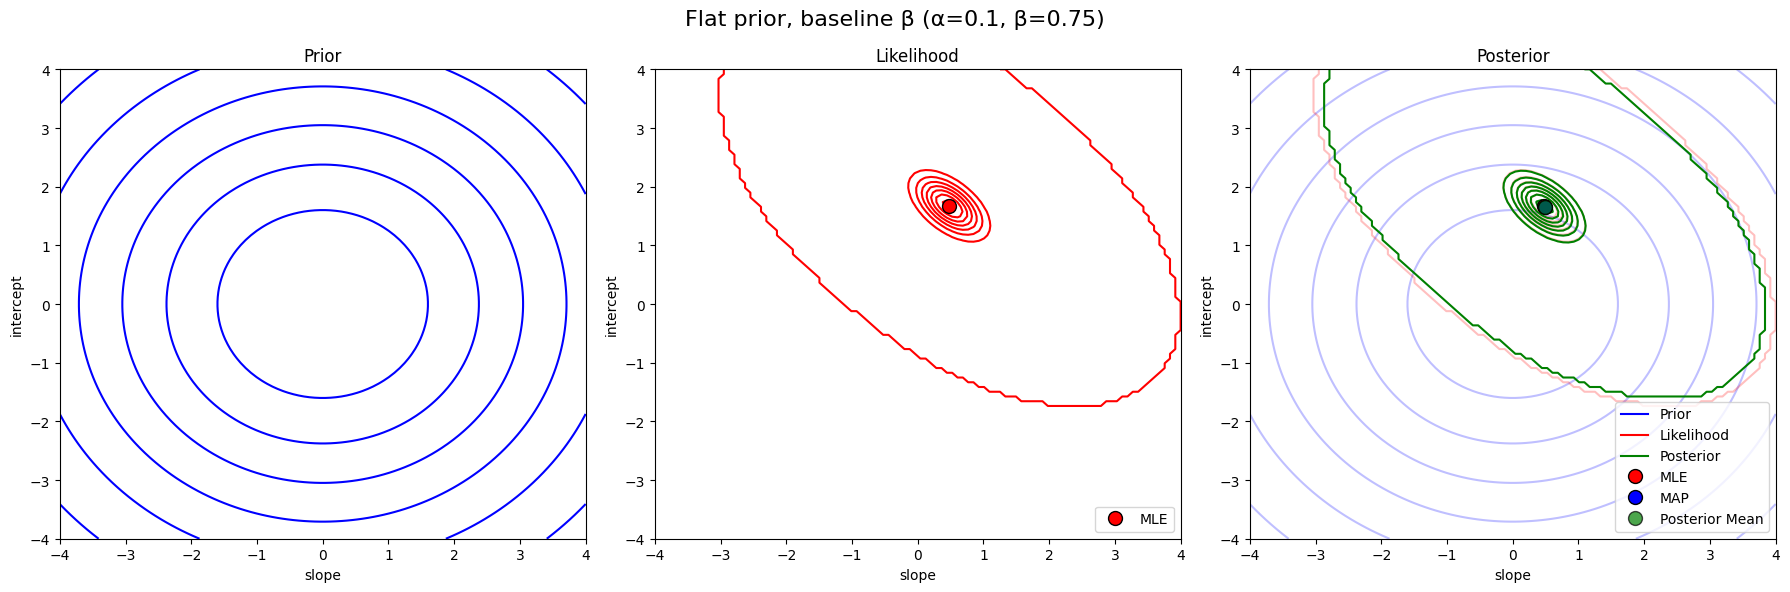


Configuration 2: Strong prior, baseline β
Alpha: 20, Beta: 0.75
MLE: [0.4804374 1.6728646]
MAP: [0.43174583 0.7474632 ]
Posterior Mean: [0.4317459 0.7474633]


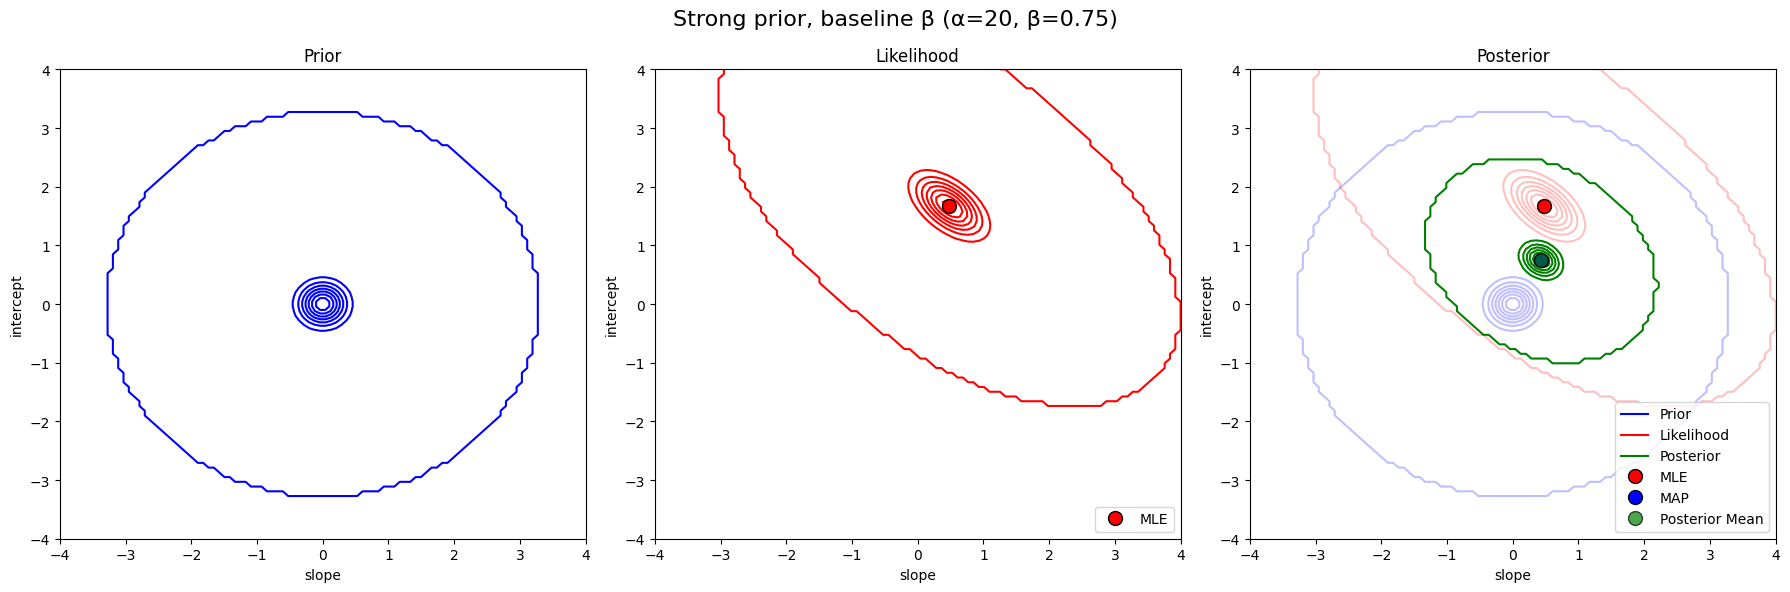


Configuration 3: High‑noise likelihood (β ↓)
Alpha: 5, Beta: 0.1
MLE: [0.4804374 1.6728646]
MAP: [0.3250438  0.51874036]
Posterior Mean: [0.3250438 0.5187403]


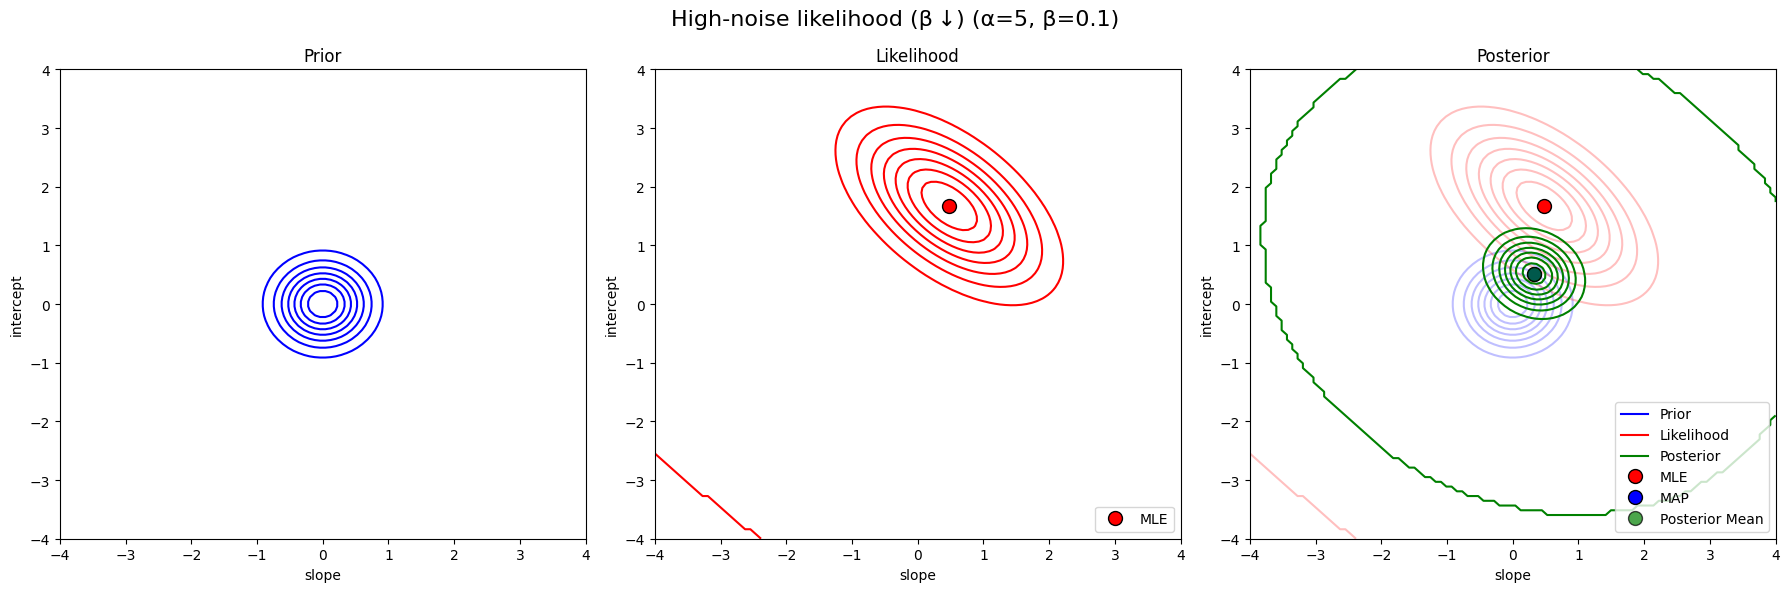


Configuration 4: Low‑noise likelihood (β ↑)c
Alpha: 5, Beta: 10
MLE: [0.4804374 1.6728646]
MAP: [0.49456155 1.6263486 ]
Posterior Mean: [0.49456188 1.6263486 ]


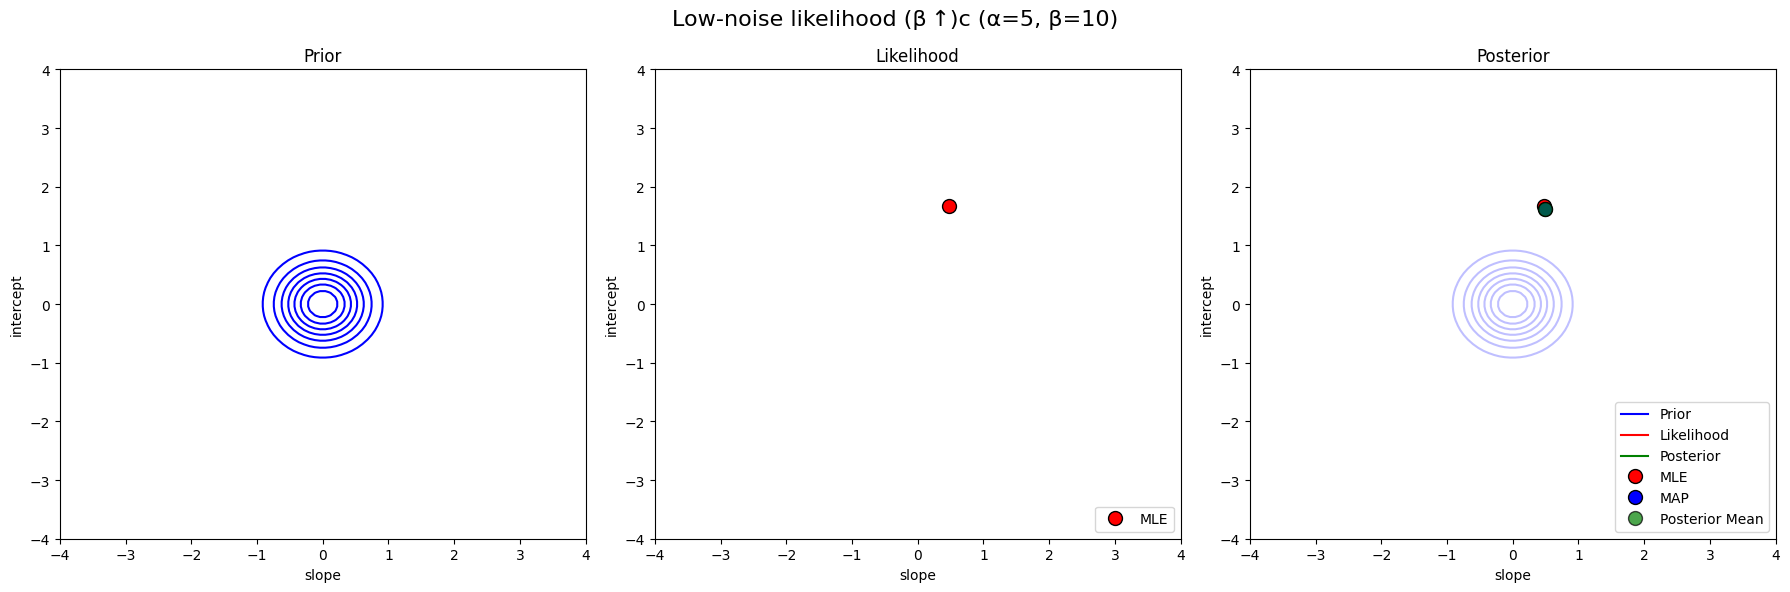


Configuration 5: Almost flat prior + low noise
Alpha: 0.001, Beta: 5
MLE: [0.4804374 1.6728646]
MAP: [0.4804436 1.672845 ]
Posterior Mean: [0.480444  1.6728448]


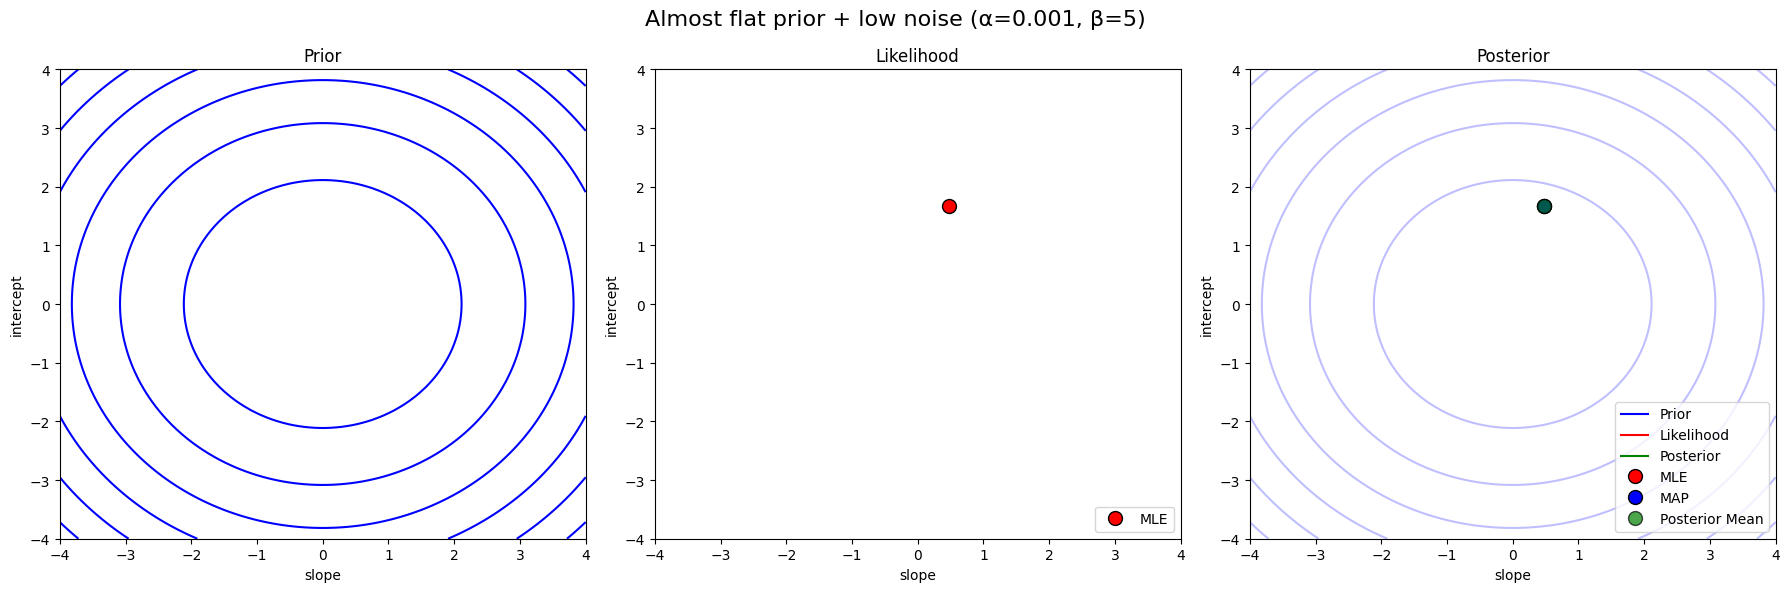


Configuration 6: Flat-ish prior + low noise
Alpha: 0.01, Beta: 5
MLE: [0.4804374 1.6728646]
MAP: [0.4804994 1.6726708]
Posterior Mean: [0.4804996 1.6726704]


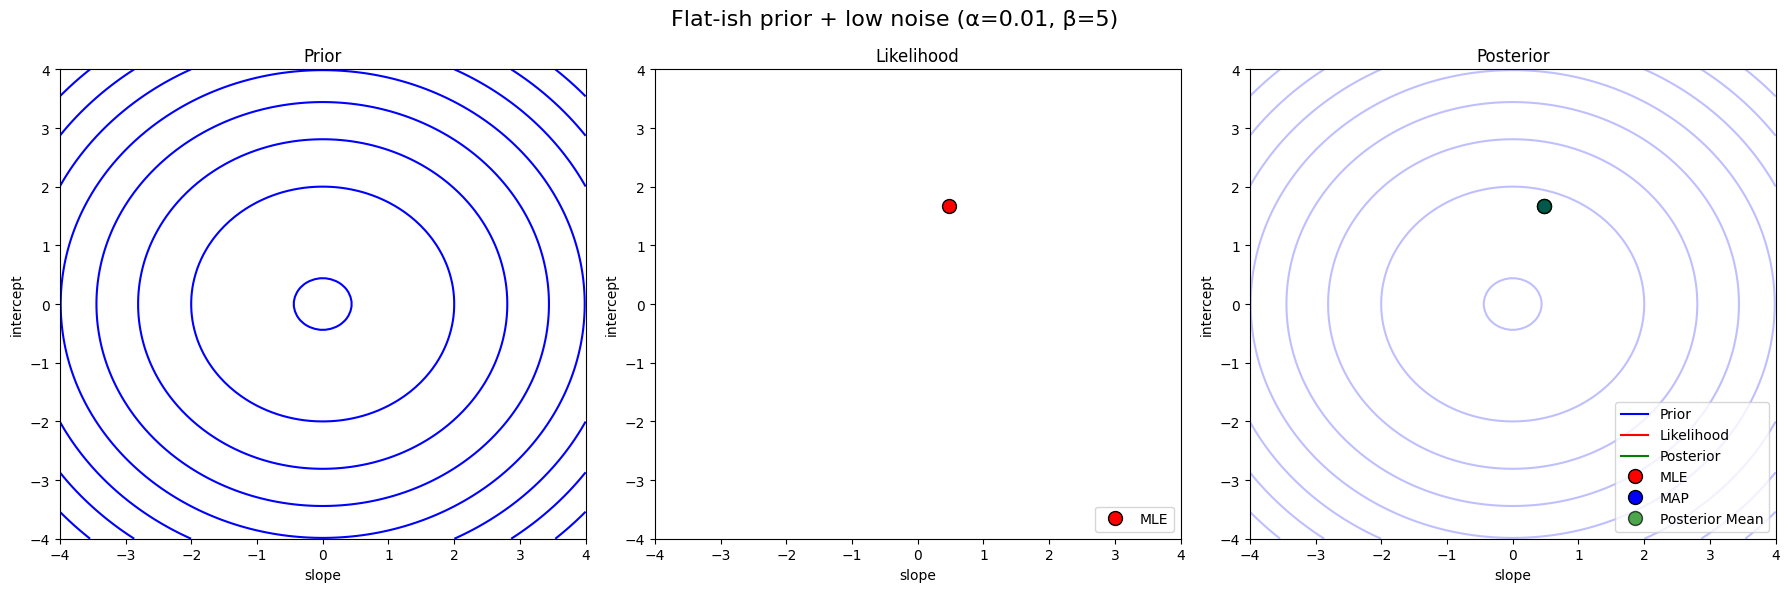


Configuration 7: Flat-ish prior + low noise
Alpha: 0.1, Beta: 5
MLE: [0.4804374 1.6728646]
MAP: [0.48105717 1.6709316 ]
Posterior Mean: [0.48105705 1.6709313 ]


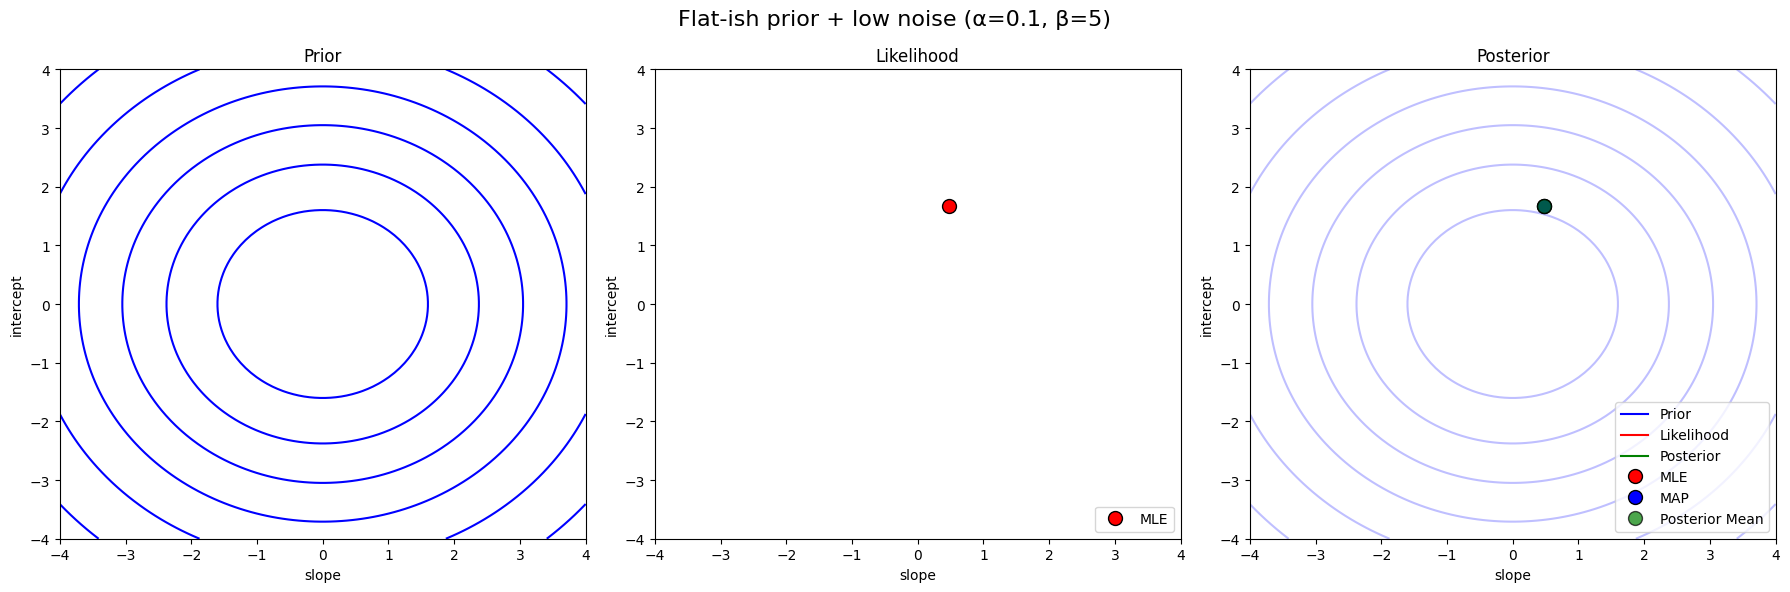


Configuration 8: Moderate prior, low noise
Alpha: 1.0, Beta: 5
MLE: [0.4804374 1.6728646]
MAP: [0.4864211 1.6538141]
Posterior Mean: [0.4864217 1.6538137]


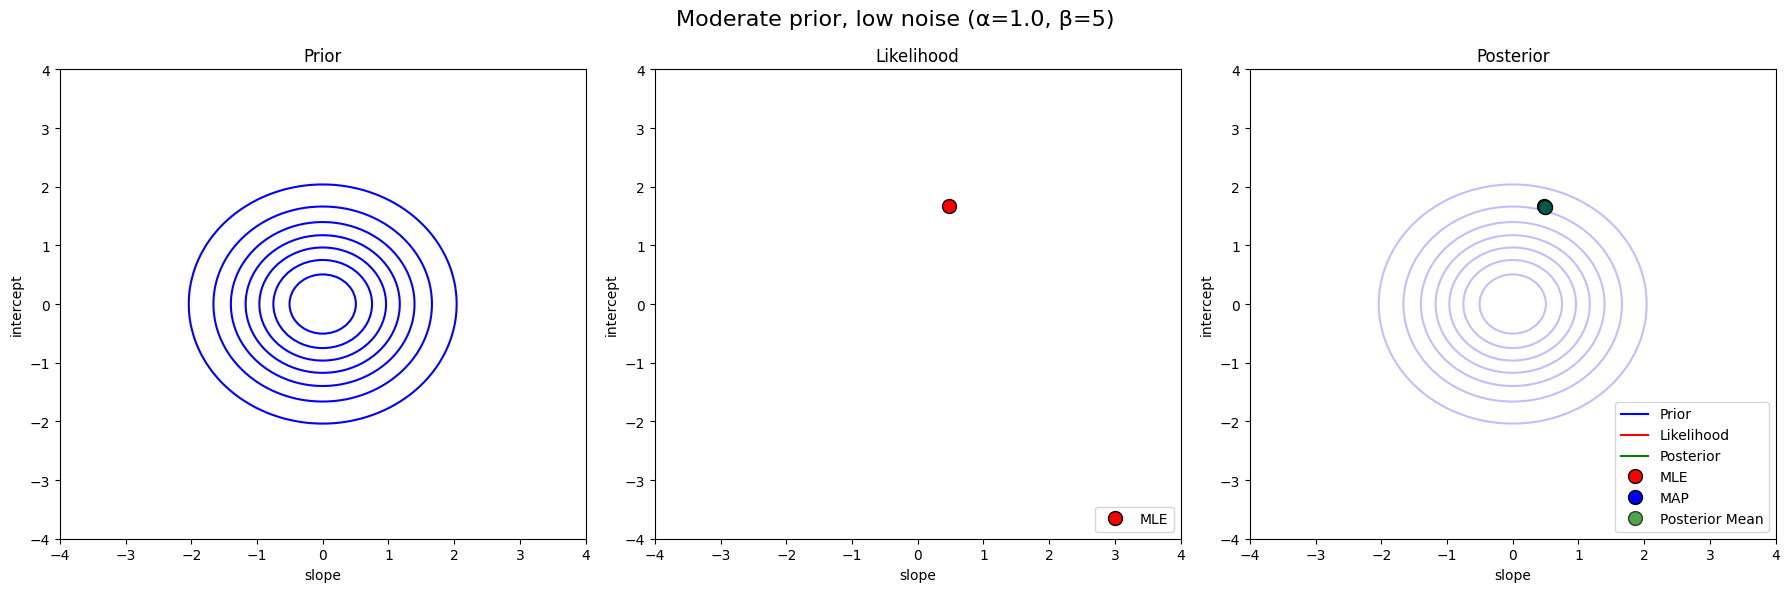


Configuration 9: Strong prior + low noise
Alpha: 10, Beta: 5
MLE: [0.4804374 1.6728646]
MAP: [0.52327335 1.5057502 ]
Posterior Mean: [0.5232734 1.5057498]


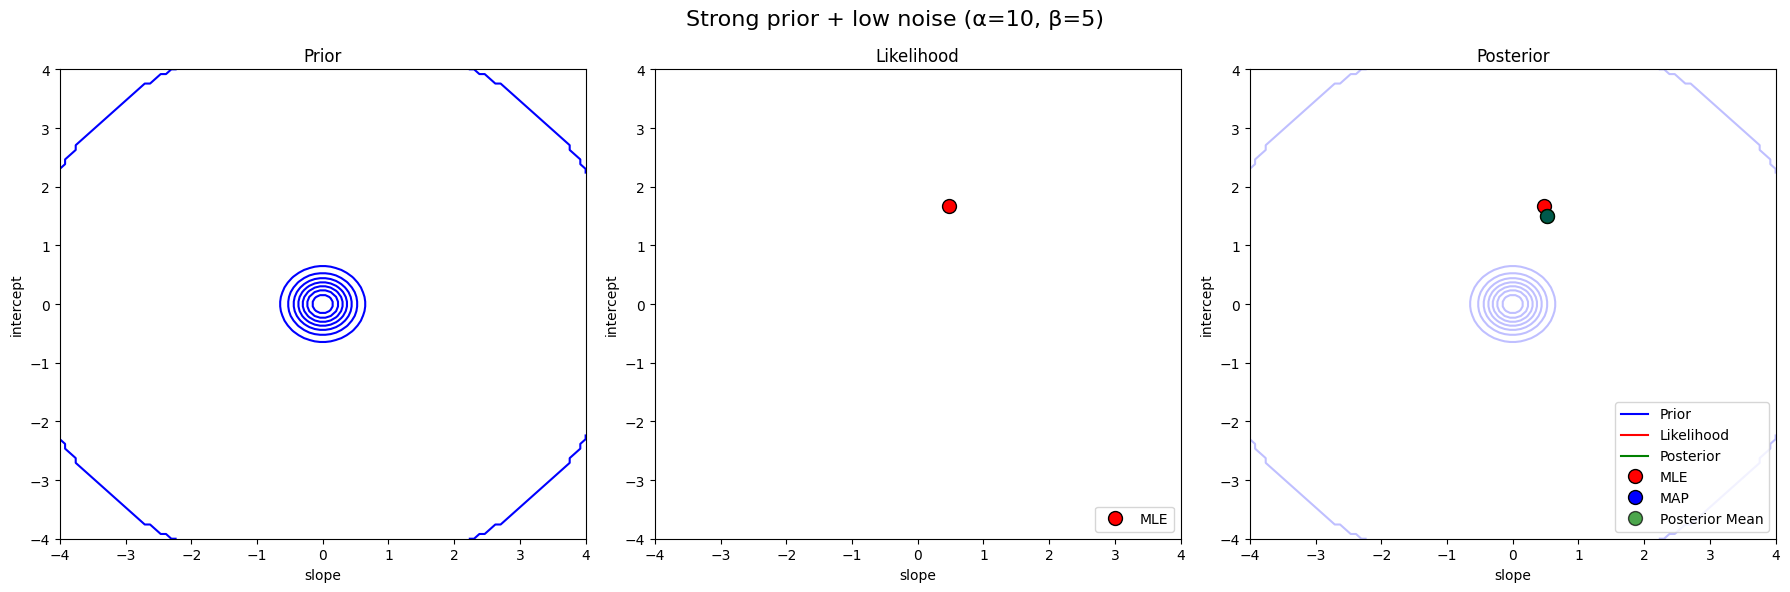

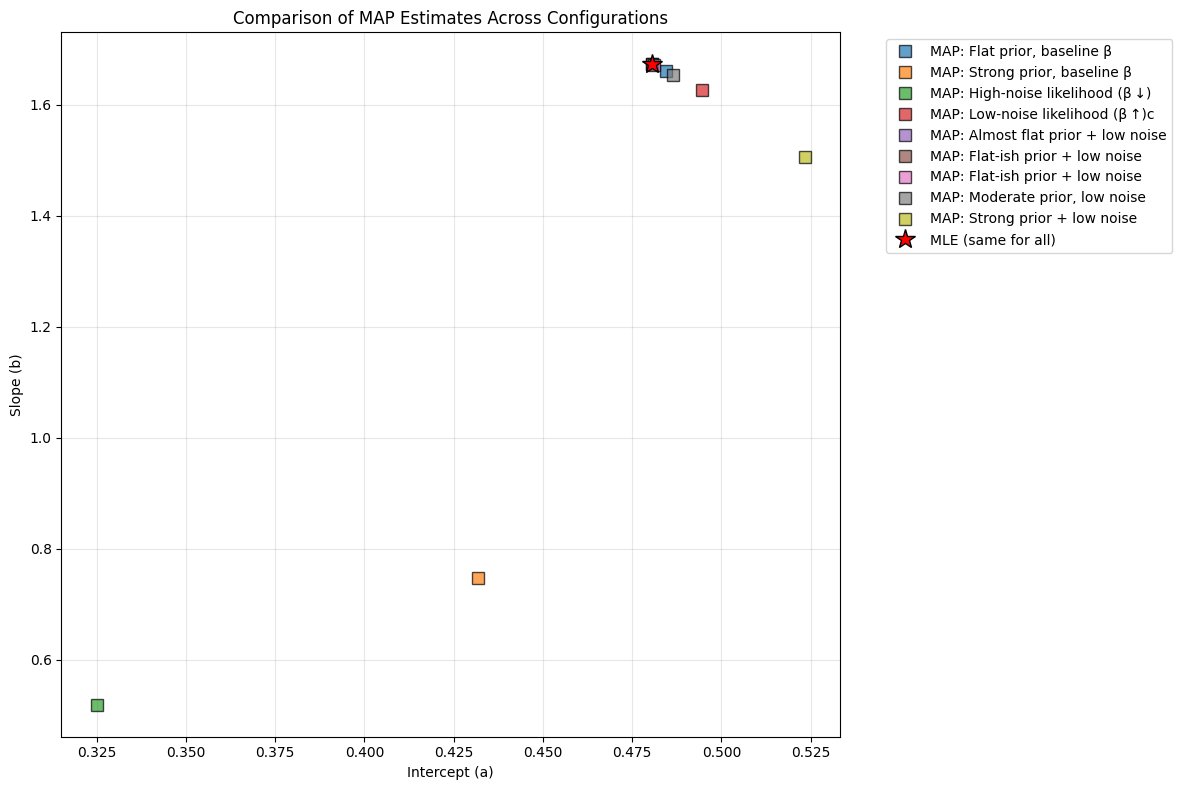

In [26]:
import jax.numpy as jnp
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal

# Data
N = 20
# Define training input data (x values), shape (N, 1)
xtrain = jnp.array([1.764, 0.4, 0.979, 2.241, 1.868, -0.977, 0.95, -0.151, -0.103, 0.411, 0.144, 1.454, 0.761, 0.122,
0.444, 0.334, 1.494, -0.205, 0.313, -0.854])[:, None]  # shape (N, 1)
# Define training output data (y values), shape (N, 1)
ytrain = jnp.array([-0.464, 2.024, 3.191, 2.812, 6.512, -3.022, 1.99, 0.009, 2.513, 3.194, 0.935, 3.216, 0.386, -2.118,
0.674, 1.222, 4.481, 1.893, 0.422, -1.209])[:, None]  # shape (N, 1)

# Configurations to test
configs = [
    {"alpha": 0.1, "beta": 3/4, "title": "Flat prior, baseline β"},
    {"alpha": 20, "beta": 3/4, "title": "Strong prior, baseline β"},
    {"alpha": 5, "beta": 0.1, "title": "High‑noise likelihood (β ↓)"},
    {"alpha": 5, "beta": 10, "title": "Low‑noise likelihood (β ↑)c"},
    {"alpha": 1e-3, "beta": 5, "title": "Almost flat prior + low noise"},
    {"alpha": 1e-2, "beta": 5, "title": "Flat-ish prior + low noise"},
    {"alpha": 1e-1, "beta": 5, "title": "Flat-ish prior + low noise"},
    {"alpha": 1., "beta": 5, "title": "Moderate prior, low noise"},
    {"alpha": 10, "beta": 5, "title": "Strong prior + low noise"},
]

# --- Helper functions (modified to accept alpha and beta) ---

log_npdf = lambda x, m, v: -0.5 * jnp.log(2 * jnp.pi * v) - 0.5 * (x - m) ** 2 / v
predict = lambda x, a, b: a + b * x

def log_prior(x, y, a, b, alpha):
    """
    Compute the log prior probability of parameters (a, b).
    """
    return multivariate_normal.logpdf(jnp.column_stack([a, b]), jnp.array([0, 0]), 1/alpha*jnp.identity(2))

def log_likelihood(x, y, a, b, beta):
    """
    Compute the total log likelihood of observed targets y given inputs x and parameters (a, b).
    """
    y_pred = predict(x, a, b)
    return jnp.sum(log_npdf(y, y_pred, 1 / beta), axis=0)

def log_posterior(x, y, a, b, alpha, beta):
    """
    Compute the log posterior (unnormalized) of parameters (a, b) given data (x, y).
    """
    return log_prior(x, y, a, b, alpha) + log_likelihood(x, y, a, b, beta)

def design_matrix(x):
    """
    Construct a design matrix Φ with a bias (intercept) term.
    """
    return jnp.column_stack((jnp.ones(len(x)), x))

def compute_mle(xtrain, ytrain):
    """
    Computes the Maximum Likelihood Estimate (MLE) weights for linear regression using a design matrix.
    """
    Phi = design_matrix(xtrain)
    w_mle = jnp.linalg.inv(Phi.T @ Phi) @ (Phi.T @ ytrain)
    return w_mle

def compute_map(xtrain, ytrain, alpha, beta):
    """
    Computes the Maximum A Posteriori (MAP) estimate for Bayesian linear regression.
    """
    Phi = design_matrix(xtrain)  # Shape (n, d)
    d = Phi.shape[1] 
    lambda_matrix = (alpha / beta) * jnp.eye(d) # shape (d, d)
    w_map = jnp.linalg.inv(Phi.T @ Phi + lambda_matrix) @ (Phi.T @ ytrain) # shape (d,)
    return w_map

def posterior_mean(xtrain, ytrain, beta, alpha):
    """
    Computes the posterior mean of the weights in Bayesian linear regression.
    """
    Phi = design_matrix(xtrain)      # Shape (n, d)
    d = Phi.shape[1]
    S = jnp.linalg.inv(alpha * jnp.eye(d) + beta * Phi.T @ Phi) # shape (d, d)
    m = beta * S @ Phi.T @ ytrain # shape (d,)
    return m

def plot_distribution(ax, x, y, density_fun, alpha_val, beta_val, color=None, visibility=1, label=None, title=None, num_points=100):
    """
    Plots the contour of a density function over a grid of slope (a) and intercept (b) values.
    """
    # Create grid for parameters (a: slope, b: intercept)
    a_array = jnp.linspace(-4, 4, num_points)
    b_array = jnp.linspace(-4, 4, num_points)
    A_array, B_array = jnp.meshgrid(a_array, b_array)
    # Form array with all combinations of (a, b) in our grid
    AB = jnp.column_stack((A_array.ravel(), B_array.ravel()))
    
    # Evaluate density for every point in the grid and reshape back
    if 'prior' in str(density_fun):
        Z = density_fun(x, y, A_array.ravel(), B_array.ravel(), alpha_val)
    elif 'likelihood' in str(density_fun):
        Z = density_fun(x, y, A_array.ravel(), B_array.ravel(), beta_val)
    else:  # posterior
        Z = density_fun(x, y, A_array.ravel(), B_array.ravel(), alpha_val, beta_val)
    
    Z = Z.reshape((len(a_array), len(b_array)))
    # Plot contour of the density
    ax.contour(a_array, b_array, jnp.exp(Z), colors=color, alpha=visibility)
    # Add a dummy plot for legend
    ax.plot([-1000], [-1000], color=color, label=label)
    # Set axis labels, limits, and title
    ax.set(xlabel='slope', ylabel='intercept', xlim=(-4, 4), ylim=(-4, 4), title=title)

def plot_toydata(ax):
    """Function to plot the toy dataset"""
    ax.plot(xtrain, ytrain, 'k.', label='Data', markersize=12)  # plot data points as black dots
    ax.set(xlabel='Input x', ylabel='Response y', xlim=(-3, 3), ylim=(-6, 6))  # set axis labels and limits
    ax.legend()  # show legend

# Plot the toy data first
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
plot_toydata(ax)
plt.show()

# Create plots for each configuration
for i, config in enumerate(configs):
    alpha = config["alpha"]
    beta = config["beta"]
    title = config["title"]
    
    print(f"\nConfiguration {i+1}: {title}")
    print(f"Alpha: {alpha}, Beta: {beta}")
    
    # Calculate estimates
    MLE = compute_mle(xtrain, ytrain)
    MAP = compute_map(xtrain, ytrain, alpha, beta)
    P_MEAN = posterior_mean(xtrain, ytrain, beta, alpha)
    
    print(f"MLE: {MLE.ravel()}")
    print(f"MAP: {MAP.ravel()}")
    print(f"Posterior Mean: {P_MEAN.ravel()}")
    
    # Create figure with 3 subplots
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle(f"{title} (α={alpha}, β={beta})", fontsize=16)
    
    # Plot prior
    plot_distribution(axes[0], xtrain, ytrain, density_fun=log_prior, 
                     alpha_val=alpha, beta_val=beta, color='b', title='Prior')
    
    # Plot likelihood
    plot_distribution(axes[1], xtrain, ytrain, density_fun=log_likelihood, 
                     alpha_val=alpha, beta_val=beta, color='r', title='Likelihood')
    
    # Plot posterior with overlays
    plot_distribution(axes[2], xtrain, ytrain, density_fun=log_prior, 
                     alpha_val=alpha, beta_val=beta, color='b', visibility=0.25, label='Prior')
    plot_distribution(axes[2], xtrain, ytrain, density_fun=log_likelihood, 
                     alpha_val=alpha, beta_val=beta, color='r', visibility=0.25, label='Likelihood')
    plot_distribution(axes[2], xtrain, ytrain, density_fun=log_posterior, 
                     alpha_val=alpha, beta_val=beta, color='g', label='Posterior', title='Posterior')
    
    # Add MLE point to likelihood plot
    axes[1].plot([MLE[0]], [MLE[1]], 
                 marker='o', markerfacecolor='red', markeredgecolor='black', 
                 linestyle='none', label='MLE', ms=10)
    
    # Add all estimates to posterior plot
    axes[2].plot([MLE[0]], [MLE[1]], 
                 marker='o', markerfacecolor='red', markeredgecolor='black', 
                 linestyle='none', label='MLE', ms=10)
    
    axes[2].plot([MAP[0]], [MAP[1]], 
                 marker='o', markerfacecolor='blue', markeredgecolor='black', 
                 linestyle='none', label='MAP', ms=10)
    
    axes[2].plot([P_MEAN[0]], [P_MEAN[1]], 
                 marker='o', markerfacecolor='green', markeredgecolor='black', 
                 linestyle='none', label='Posterior Mean', ms=10, alpha=0.7)
    
    # Add legends
    axes[1].legend(loc='lower right')
    axes[2].legend(loc='lower right')
    
    plt.tight_layout()
    plt.savefig(f"bayesian_linear_regression_{i+1}.png")
    plt.show()

# Summary comparison plot showing just the estimates
fig, ax = plt.subplots(1, 1, figsize=(12, 8))
colors = plt.cm.tab10(range(len(configs)))

MLE_base = compute_mle(xtrain, ytrain)

for i, config in enumerate(configs):
    alpha = config["alpha"]
    beta = config["beta"]
    title = config["title"]
    
    MAP = compute_map(xtrain, ytrain, alpha, beta)
    P_MEAN = posterior_mean(xtrain, ytrain, beta, alpha)
    
    # Plot MAP estimates
    ax.plot([MAP[0]], [MAP[1]], 
            marker='s', markerfacecolor=colors[i], markeredgecolor='black', 
            linestyle='none', label=f'MAP: {title}', ms=8, alpha=0.7)

# Plot MLE (same for all configurations)
ax.plot([MLE_base[0]], [MLE_base[1]], 
        marker='*', markerfacecolor='red', markeredgecolor='black', 
        linestyle='none', label='MLE (same for all)', ms=15)

ax.set(xlabel='Intercept (a)', ylabel='Slope (b)', title='Comparison of MAP Estimates Across Configurations')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()